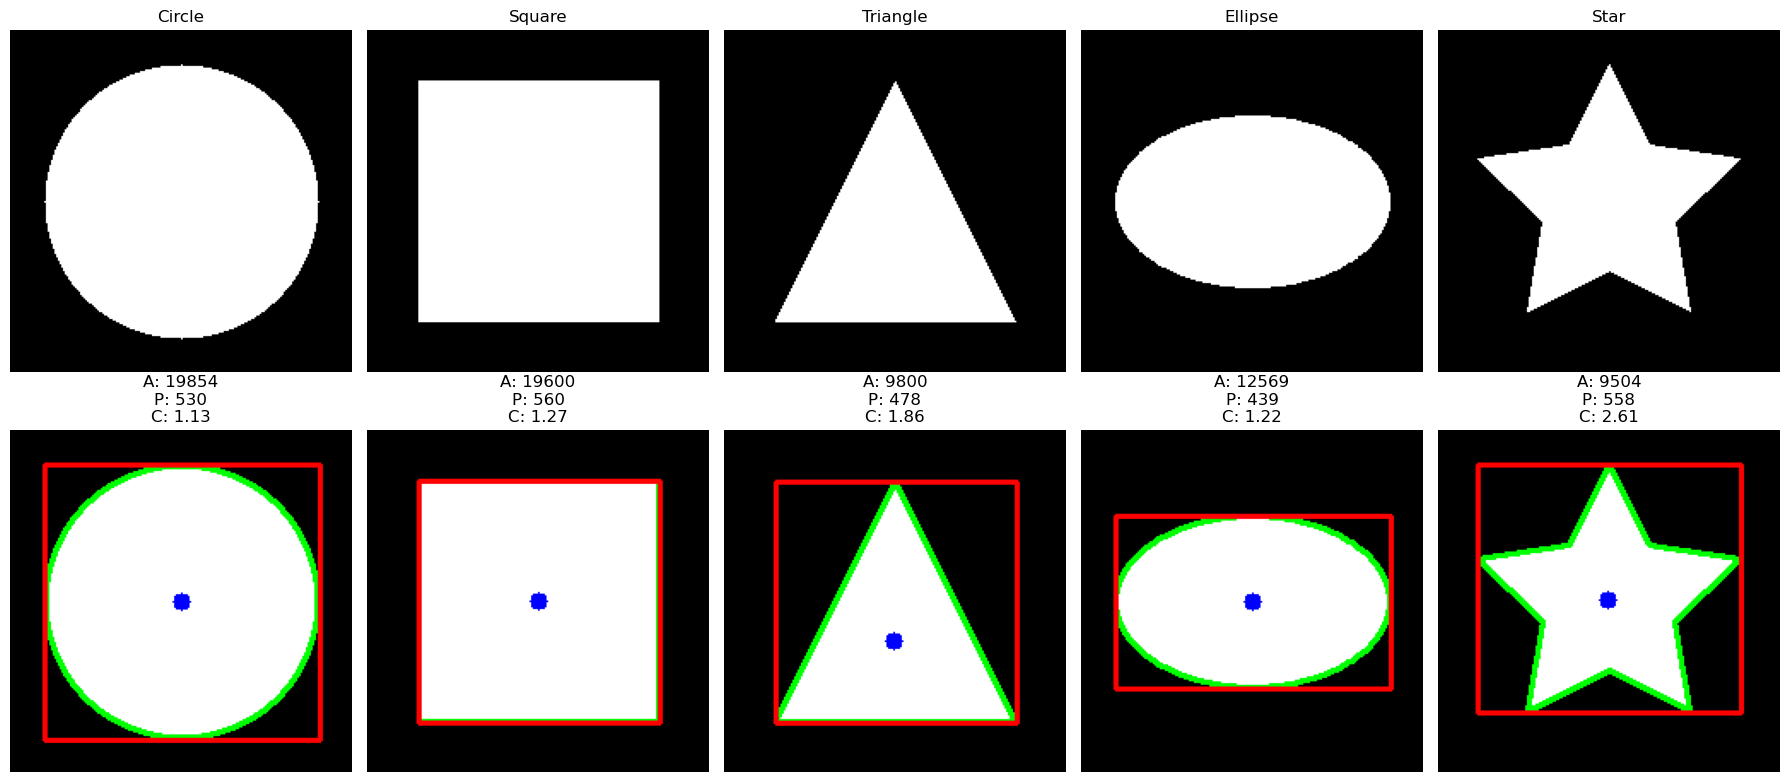

COMPREHENSIVE SHAPE ANALYSIS
Shape      Area     Perimeter  Compactness  Aspect Ratio Extent     Equi Diameter  
------------------------------------------------------------------------------------------
Circle     19854    530        1.13         1.00         0.77       159.0          
Square     19600    560        1.27         1.00         0.99       158.0          
Triangle   9800     478        1.86         1.00         0.49       111.7          
Ellipse    12569    439        1.22         1.59         0.77       126.5          
Star       9504     558        2.61         1.06         0.43       110.0          

HU MOMENTS ANALYSIS (log scale, invariant to rotation, scale, translation)
Shape      Hu1          Hu2          Hu3          Hu4         
--------------------------------------------------------------------------------
Circle     0.80         0.00         10.00        10.00       
Square     0.78         0.00         10.00        10.00       
Triangle   0.71         3.11  

In [1]:
# ==============================================================
# Latihan 1: Analisis Properti Region dan Moments
# ==============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def latihan_1():
    # Buat berbagai bentuk geometris untuk analisis
    shapes = []
    shape_names = []
    
    # 1. Lingkaran (perfect circle)
    circle = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(circle, (100, 100), 80, 255, -1)
    shapes.append(circle)
    shape_names.append("Circle")
    
    # 2. Persegi (square)
    square = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(square, (30, 30), (170, 170), 255, -1)
    shapes.append(square)
    shape_names.append("Square")
    
    # 3. Segitiga (triangle)
    triangle = np.zeros((200, 200), dtype=np.uint8)
    pts = np.array([[100, 30], [30, 170], [170, 170]])
    cv2.fillPoly(triangle, [pts], 255)
    shapes.append(triangle)
    shape_names.append("Triangle")
    
    # 4. Elips (ellipse)
    ellipse = np.zeros((200, 200), dtype=np.uint8)
    cv2.ellipse(ellipse, (100, 100), (80, 50), 0, 0, 360, 255, -1)
    shapes.append(ellipse)
    shape_names.append("Ellipse")
    
    # 5. Bintang (star - complex shape)
    star = np.zeros((200, 200), dtype=np.uint8)
    points = []
    for i in range(10):
        angle = i * 2 * np.pi / 10
        radius = 80 if i % 2 == 0 else 40
        x = 100 + radius * np.cos(angle - np.pi/2)
        y = 100 + radius * np.sin(angle - np.pi/2)
        points.append([x, y])
    pts = np.array(points, dtype=np.int32)
    cv2.fillPoly(star, [pts], 255)
    shapes.append(star)
    shape_names.append("Star")
    
    # Analisis setiap bentuk
    shape_data = []
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    
    for i, (shape, name) in enumerate(zip(shapes, shape_names)):
        # Temukan contours
        contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contour = contours[0]
        
        # 1. Basic region properties
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        # 2. Moments calculation
        M = cv2.moments(contour)
        
        # Centroid dari moments
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
        
        # 3. Bounding box properties
        x, y, w, h = cv2.boundingRect(contour)
        
        # 4. Hu moments (7 invariant moments)
        hu_moments = cv2.HuMoments(M).flatten()
        
        # 5. Shape descriptors
        compactness = (perimeter ** 2) / (4 * np.pi * area) if area > 0 else float('inf')
        aspect_ratio = w / h if h > 0 else 0
        
        # Equivalent diameter
        equi_diameter = np.sqrt(4 * area / np.pi)
        
        # Extent (ratio of contour area to bounding rectangle area)
        rect_area = w * h
        extent = area / rect_area if rect_area > 0 else 0
        
        # Simpan data
        shape_info = {
            'name': name,
            'area': area,
            'perimeter': perimeter,
            'centroid': (cx, cy),
            'compactness': compactness,
            'aspect_ratio': aspect_ratio,
            'extent': extent,
            'equi_diameter': equi_diameter,
            'hu_moments': hu_moments
        }
        shape_data.append(shape_info)
        
        # Visualisasi bentuk dengan annotations
        display_img = cv2.cvtColor(shape, cv2.COLOR_GRAY2BGR)
        
        # Draw contour
        cv2.drawContours(display_img, [contour], -1, (0, 255, 0), 2)
        
        # Draw centroid
        cv2.circle(display_img, (cx, cy), 5, (255, 0, 0), -1)
        
        # Draw bounding box
        cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 0, 255), 2)
        
        # Row 0: Original shapes
        axes[0, i].imshow(shape, cmap='gray')
        axes[0, i].set_title(name)
        axes[0, i].axis('off')
        
        # Row 1: Annotated shapes
        axes[1, i].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
        title = f'A: {area:.0f}\nP: {perimeter:.0f}\nC: {compactness:.2f}'
        axes[1, i].set_title(title)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display comprehensive analysis table
    print("COMPREHENSIVE SHAPE ANALYSIS")
    print("=" * 90)
    print(f"{'Shape':<10} {'Area':<8} {'Perimeter':<10} {'Compactness':<12} {'Aspect Ratio':<12} {'Extent':<10} {'Equi Diameter':<15}")
    print("-" * 90)
    
    for data in shape_data:
        print(f"{data['name']:<10} {data['area']:<8.0f} {data['perimeter']:<10.0f} "
              f"{data['compactness']:<12.2f} {data['aspect_ratio']:<12.2f} "
              f"{data['extent']:<10.2f} {data['equi_diameter']:<15.1f}")
    
    # Hu moments analysis (log scale for comparison)
    print("\nHU MOMENTS ANALYSIS (log scale, invariant to rotation, scale, translation)")
    print("=" * 80)
    print(f"{'Shape':<10} {'Hu1':<12} {'Hu2':<12} {'Hu3':<12} {'Hu4':<12}")
    print("-" * 80)
    
    for data in shape_data:
        hu = data['hu_moments']
        # Convert to log scale for better comparison
        hu_log = [-np.sign(h) * np.log10(abs(h) + 1e-10) if h != 0 else 0 for h in hu[:4]]
        print(f"{data['name']:<10} {hu_log[0]:<12.2f} {hu_log[1]:<12.2f} "
              f"{hu_log[2]:<12.2f} {hu_log[3]:<12.2f}")
    
    # Shape classification demonstration
    print("\nSHAPE CLASSIFICATION DEMONSTRATION")
    print("=" * 40)
    
    # Simple classification based on compactness
    for data in shape_data:
        if data['compactness'] < 1.1:
            category = "Circle-like"
        elif data['compactness'] < 1.5:
            category = "Regular polygon"
        else:
            category = "Complex shape"
        
        print(f"{data['name']}: Compactness = {data['compactness']:.2f} → {category}")
    
    return shape_data

# Jalankan latihan 1
shape_analysis_data = latihan_1()

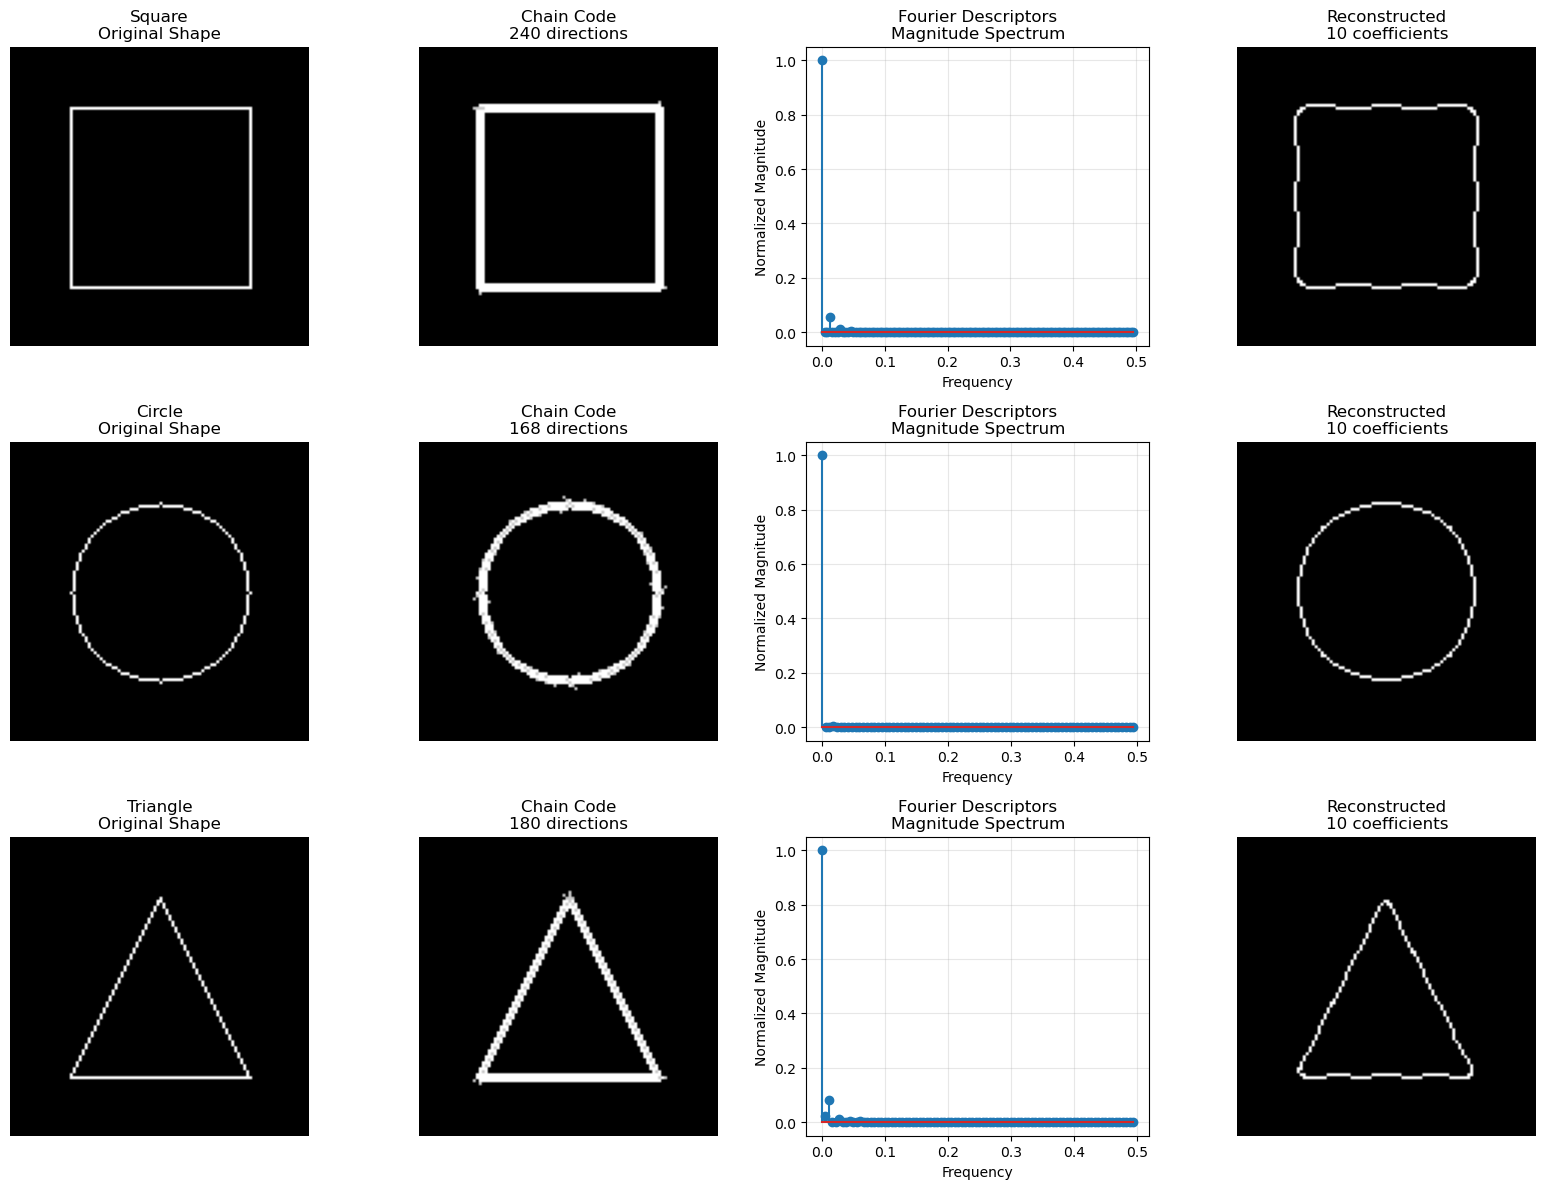

CHAIN CODE ANALYSIS

Square:
  Number of chain codes: 240
  First 10 codes: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Direction frequency:
    East: 60
    South: 60
    West: 60
    North: 60

Circle:
  Number of chain codes: 168
  First 10 codes: [3, 4, 4, 4, 4, 4, 4, 3, 4, 4]
  Direction frequency:
    East: 24
    SE: 18
    South: 24
    SW: 18
    West: 24
    NW: 18
    North: 24
    NE: 18

Triangle:
  Number of chain codes: 180
  First 10 codes: [3, 2, 3, 2, 3, 2, 3, 2, 3, 2]
  Direction frequency:
    East: 60
    South: 30
    SW: 30
    NW: 30
    North: 30

FOURIER DESCRIPTORS FOR SHAPE MATCHING
Shape similarity (Euclidean distance between Fourier descriptors):
  Square vs Circle: 0.0519
  Square vs Triangle: 0.1011
  Circle vs Triangle: 0.0860

Interpretation:
• Smaller distance = more similar shapes
• Larger distance = less similar shapes
• Fourier descriptors are invariant to rotation and scale


In [2]:
# ==============================================================
# Latihan 2: Chain Codes dan Fourier Descriptors
# ==============================================================

def latihan_2():
    # Buat bentuk sederhana untuk analisis boundary
    shapes = []
    
    # 1. Persegi (untuk chain code sederhana)
    square = np.zeros((100, 100), dtype=np.uint8)
    cv2.rectangle(square, (20, 20), (80, 80), 255, 1)  # Outline only
    shapes.append(('Square', square))
    
    # 2. Lingkaran (untuk Fourier analysis)
    circle = np.zeros((100, 100), dtype=np.uint8)
    cv2.circle(circle, (50, 50), 30, 255, 1)
    shapes.append(('Circle', circle))
    
    # 3. Segitiga (bentuk sederhana tapi non-simetris)
    triangle = np.zeros((100, 100), dtype=np.uint8)
    pts = np.array([[50, 20], [20, 80], [80, 80]])
    cv2.polylines(triangle, [pts], True, 255, 1)
    shapes.append(('Triangle', triangle))
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    for row, (name, shape) in enumerate(shapes):
        # Dapatkan contour
        contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contour = contours[0]
        
        # Simplifikasi contour untuk chain code
        contour_simple = []
        for i in range(len(contour)):
            if i == 0 or not np.array_equal(contour[i][0], contour[i-1][0]):
                contour_simple.append(contour[i][0])
        contour_simple = np.array(contour_simple)
        
        # 1. Original shape
        axes[row, 0].imshow(shape, cmap='gray')
        axes[row, 0].set_title(f'{name}\nOriginal Shape')
        axes[row, 0].axis('off')
        
        # 2. Freeman Chain Code (8-directional)
        def freeman_chain_code_8dir(points):
            """Calculate 8-directional Freeman chain code"""
            if len(points) < 2:
                return []
            
            directions_8 = [
                (1, 0),   # 0: East
                (1, 1),   # 1: Southeast
                (0, 1),   # 2: South
                (-1, 1),  # 3: Southwest
                (-1, 0),  # 4: West
                (-1, -1), # 5: Northwest
                (0, -1),  # 6: North
                (1, -1)   # 7: Northeast
            ]
            
            chain_code = []
            for i in range(len(points)):
                current = points[i]
                next_point = points[(i + 1) % len(points)]
                
                dx = next_point[0] - current[0]
                dy = next_point[1] - current[1]
                
                # Cari direction yang cocok
                for dir_code, (dir_dx, dir_dy) in enumerate(directions_8):
                    if dx == dir_dx and dy == dir_dy:
                        chain_code.append(dir_code)
                        break
            
            return chain_code
        
        chain_code = freeman_chain_code_8dir(contour_simple)
        
        # Visualisasi chain code
        chain_display = np.zeros((100, 100), dtype=np.uint8)
        for i, point in enumerate(contour_simple):
            cv2.circle(chain_display, tuple(point), 1, 255, -1)
            if i < len(chain_code):
                # Gambar arrow untuk direction
                dir_code = chain_code[i]
                directions = [(1,0), (1,1), (0,1), (-1,1), (-1,0), (-1,-1), (0,-1), (1,-1)]
                dx, dy = directions[dir_code]
                end_point = (point[0] + dx*3, point[1] + dy*3)
                cv2.arrowedLine(chain_display, tuple(point), end_point, 200, 1)
        
        axes[row, 1].imshow(chain_display, cmap='gray')
        axes[row, 1].set_title(f'Chain Code\n{len(chain_code)} directions')
        axes[row, 1].axis('off')
        
        # 3. Fourier Descriptors
        def compute_fourier_descriptors(points, num_descriptors=20):
            """Compute Fourier descriptors from boundary points"""
            # Convert points to complex numbers
            z = points[:, 0] + 1j * points[:, 1]
            
            # Apply Fourier Transform
            fd = np.fft.fft(z)
            
            # Get magnitude spectrum
            fd_magnitude = np.abs(fd)
            
            # Normalize (divide by DC component)
            if fd_magnitude[0] != 0:
                fd_normalized = fd_magnitude / fd_magnitude[0]
            else:
                fd_normalized = fd_magnitude
            
            return fd, fd_normalized
        
        # Pastikan kita punya cukup points untuk Fourier analysis
        if len(contour_simple) > 10:
            # Resample points untuk uniform sampling
            num_samples = min(256, len(contour_simple))
            indices = np.linspace(0, len(contour_simple)-1, num_samples).astype(int)
            sampled_points = contour_simple[indices]
            
            fd, fd_norm = compute_fourier_descriptors(sampled_points, 20)
            
            # Plot Fourier descriptors magnitude
            n = len(fd_norm)
            frequencies = np.fft.fftfreq(n)
            
            axes[row, 2].stem(frequencies[:n//2], fd_norm[:n//2])
            axes[row, 2].set_title('Fourier Descriptors\nMagnitude Spectrum')
            axes[row, 2].set_xlabel('Frequency')
            axes[row, 2].set_ylabel('Normalized Magnitude')
            axes[row, 2].grid(True, alpha=0.3)
            
            # 4. Shape reconstruction from Fourier descriptors
            def reconstruct_shape(fd, num_coeffs):
                """Reconstruct shape using limited Fourier coefficients"""
                fd_recon = fd.copy()
                # Keep only low frequency components
                fd_recon[num_coeffs:-num_coeffs] = 0
                z_recon = np.fft.ifft(fd_recon)
                return z_recon.real, z_recon.imag
            
            # Rekonstruksi dengan jumlah coefficients berbeda
            for coeff_idx, num_coeffs in enumerate([5, 10]):
                x_recon, y_recon = reconstruct_shape(fd, num_coeffs)
                
                recon_img = np.zeros((100, 100), dtype=np.uint8)
                points_recon = np.column_stack([x_recon.astype(int), y_recon.astype(int)])
                
                # Gambar reconstructed shape
                for i in range(len(points_recon)):
                    start_point = points_recon[i]
                    end_point = points_recon[(i + 1) % len(points_recon)]
                    cv2.line(recon_img, tuple(start_point), tuple(end_point), 255, 1)
                
                axes[row, 3].imshow(recon_img, cmap='gray')
                axes[row, 3].set_title(f'Reconstructed\n{num_coeffs} coefficients')
                axes[row, 3].axis('off')
        
        else:
            axes[row, 2].text(0.5, 0.5, 'Not enough points\nfor Fourier analysis', 
                            ha='center', va='center', transform=axes[row, 2].transAxes)
            axes[row, 2].axis('off')
            axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analisis chain code
    print("CHAIN CODE ANALYSIS")
    print("=" * 40)
    
    for name, shape in shapes:
        contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contour = contours[0]
        
        contour_simple = []
        for i in range(len(contour)):
            if i == 0 or not np.array_equal(contour[i][0], contour[i-1][0]):
                contour_simple.append(contour[i][0])
        
        chain_code = freeman_chain_code_8dir(contour_simple)
        
        print(f"\n{name}:")
        print(f"  Number of chain codes: {len(chain_code)}")
        print(f"  First 10 codes: {chain_code[:10]}")
        print(f"  Direction frequency:")
        for dir_code in range(8):
            count = sum(1 for code in chain_code if code == dir_code)
            if count > 0:
                directions = ['East', 'SE', 'South', 'SW', 'West', 'NW', 'North', 'NE']
                print(f"    {directions[dir_code]}: {count}")
    
    # Fourier descriptors untuk shape matching
    print("\nFOURIER DESCRIPTORS FOR SHAPE MATCHING")
    print("=" * 45)
    
    # Hitung similarity antara shapes menggunakan Fourier descriptors
    if len(shapes) >= 3:
        fd_list = []
        shape_names_list = []
        
        for name, shape in shapes[:3]:  # Ambil 3 shapes pertama
            contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            contour = contours[0]
            
            contour_simple = []
            for i in range(len(contour)):
                if i == 0 or not np.array_equal(contour[i][0], contour[i-1][0]):
                    contour_simple.append(contour[i][0])
            
            # Resample
            num_samples = 64
            indices = np.linspace(0, len(contour_simple)-1, num_samples).astype(int)
            sampled_points = np.array(contour_simple)[indices]
            
            fd, fd_norm = compute_fourier_descriptors(sampled_points, 10)
            fd_list.append(fd_norm[:10])  # Ambil 10 coefficients pertama
            shape_names_list.append(name)
        
        # Hitung Euclidean distance antara Fourier descriptors
        print("Shape similarity (Euclidean distance between Fourier descriptors):")
        for i in range(len(fd_list)):
            for j in range(i + 1, len(fd_list)):
                distance = np.sqrt(np.sum((fd_list[i] - fd_list[j]) ** 2))
                print(f"  {shape_names_list[i]} vs {shape_names_list[j]}: {distance:.4f}")
        
        print("\nInterpretation:")
        print("• Smaller distance = more similar shapes")
        print("• Larger distance = less similar shapes")
        print("• Fourier descriptors are invariant to rotation and scale")

# Jalankan latihan 2
latihan_2()